In [1]:
import os
import cv2
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
%matplotlib inline
import shutil

In [58]:
def make_xn_time_video(
    x, n, t=None,
    name="xn_trajectory.mp4",
    fps=30,
    dpi=200,
    out_size=(1920, 1080),
    linewidth=3.0,
    markersize=10.0,
    pad_frac=0.05,
    show_grid=False,
    frames_dir=None
):
    # --- inputs ---
    x = np.asarray(x, float).ravel()
    n = np.asarray(n, float).ravel()
    if t is None:
        t = np.arange(len(x), dtype=float)
    else:
        t = np.asarray(t, float).ravel()

    T = min(len(t), len(x), len(n))
    t, x, n = t[:T], x[:T], n[:T]

    # --- output paths ---
    if not name.lower().endswith(".mp4"):
        name += ".mp4"
    if frames_dir:
        os.makedirs(frames_dir, exist_ok=True)

    w, h = map(int, out_size)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(name, fourcc, fps, (w, h))
    if not writer.isOpened():
        raise RuntimeError("Could not open cv2.VideoWriter. Try a different codec/fourcc or install ffmpeg codecs.")

    # --- helpers ---
    def lims(y):
        y0, y1 = float(np.min(y)), float(np.max(y))
        if y0 == y1:
            y0 -= 1.0; y1 += 1.0
        r = y1 - y0
        return y0 - pad_frac * r, y1 + pad_frac * r

    # --- figure (match requested pixels) ---
    fig_w_in = w / dpi
    fig_h_in = h / dpi
    fig, (ax1, ax2) = plt.subplots(
        2, 1, sharex=True,
        figsize=(fig_w_in, fig_h_in),
        dpi=dpi,
        constrained_layout=True
    )
    
    ax1.tick_params(axis="y", labelsize=10)
    ax2.tick_params(axis="y", labelsize=10)
    
    for ax in (ax1, ax2):
        ax.set_facecolor("white")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        if show_grid:
            ax.grid(True, linewidth=0.5)

    ax1.set_ylabel(r"$x_c$", fontsize = 20, rotation=0, va="center", ha="center", labelpad=20)
    ax2.set_ylabel(r"$n$", fontsize = 20, rotation=0, va="center", ha="center", labelpad=20)
    ax2.set_xlabel("Time", fontsize = 20)

    ax1.set_xlim(float(t.min()), float(t.max()))
    #ax1.set_ylim(*lims(x))
    #ax2.set_ylim(*lims(n))

    ax1.set_ylim(-0.05, 1.03)
    ax2.set_ylim(-0.05, 1.03)

    ax1.set_xticks([])
    ax2.set_xticks([])

    (line_x,) = ax1.plot([], [], "-", color=(177/255, 36/255, 95/255), linewidth=linewidth)
    (pt_x,)   = ax1.plot([], [], "o", color="black", markersize=markersize)
    (line_n,) = ax2.plot([], [], "-", color=(23/255, 68/255, 127/255), linewidth=linewidth)
    (pt_n,)   = ax2.plot([], [], "o", color="black", markersize=markersize)

    try:
        #for i in range(10):
        for i in range(T):
            line_x.set_data(t[:i+1], x[:i+1])
            pt_x.set_data([t[i]], [x[i]])
            line_n.set_data(t[:i+1], n[:i+1])
            pt_n.set_data([t[i]], [n[i]])

            fig.canvas.draw()

            # Modern Matplotlib: get RGBA buffer (H, W, 4)
            rgba = np.asarray(fig.canvas.buffer_rgba())
            rgb = rgba[..., :3]  # drop alpha

            # Ensure size matches the VideoWriter
            if (rgb.shape[1], rgb.shape[0]) != (w, h):
                rgb = cv2.resize(rgb, (w, h), interpolation=cv2.INTER_AREA)

            bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)

            if frames_dir:
                cv2.imwrite(os.path.join(frames_dir, f"frame_{i:04d}.png"), bgr)

            writer.write(bgr)
    finally:
        writer.release()
        plt.close(fig)

    print(f"Saved video: {os.path.abspath(name)}")
    if frames_dir:
        print(f"Saved frames to: {os.path.abspath(frames_dir)}")


### 1. Clearance / elimination of DCCs

In [84]:
def f(k,n):
    return n / (n+k)

def x(x,alphan,betan,dt):
    return (x*(1-x)*(-(alphan+betan)*x+alphan))*dt + x

def n(n,x,eps,mu,dt):
    return (eps*x - mu*n)*dt + n

def Msfunc(alpha,beta):
    return np.array([[0, -beta],
                     [alpha, 0]])

def Mhfunc(alpha,beta):
    return np.array([[0, beta],
                     [-alpha, 0]])

def Mn(f_n,Mh,Ms):
    return (1-f_n)*Mh + f_n*Ms

#### Hostile microenvironment

\begin{equation}
\begin{aligned}
M_h =
     \begin{bmatrix}
       0 & \beta \\
      -\alpha & 0
     \end{bmatrix}, \qquad
M_s =
     \begin{bmatrix}
       0 & -\beta \\
       \alpha & 0
     \end{bmatrix}
\end{aligned}
\end{equation}
so,
\begin{equation}
\begin{aligned}
M(n) &=  \left(1-\frac{n}{n+k}\right)
     \begin{bmatrix}
       0 & \beta \\
      -\alpha & 0
     \end{bmatrix} +
     \left(\frac{n}{n+k}\right)
     \begin{bmatrix}
       0 & -\beta \\
       \alpha & 0
     \end{bmatrix} \\
     &= 
    \begin{bmatrix}
       \displaystyle 0 & \displaystyle -\beta\frac{(n-k)}{n+k} \\
       \displaystyle \alpha\frac{(n-k)}{n+k} & \displaystyle 0
    \end{bmatrix}
\end{aligned}
\end{equation}
This way,
\begin{equation}
    \dot{x_2} = x_2(1-x_2)\left( \frac{n-k}{n+k}\right) \bigl(\beta x_2 + \alpha(1-x_2) \bigr)
\end{equation}

### $\rho<k$

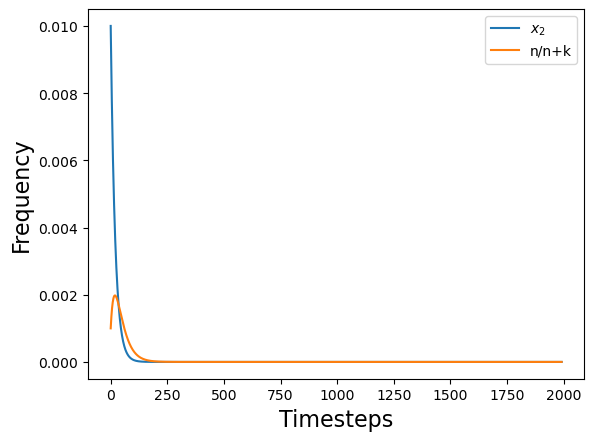

In [85]:
alpha = 0.5
beta = 0.5
eps = 0.16
mu = 0.32
k = 1

dt = 0.1
x20 = 0.01
n0 = 0.001

Mh, Ms = Mhfunc(alpha,beta), Msfunc(alpha,beta)

xs = [x20]
ns = [n0]

alphas = []
betas = []

for t in np.arange(1, 200.0001, dt):
    ns.append(n(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(f(k,ns[-1]), Mh, Ms)
    alphan = M[1,0]
    alphas.append(alphan)
    betan = M[0,1]
    betas.append(betan)
    xs.append(x(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
#plt.ylim(-0.05,1.05)
plt.show()

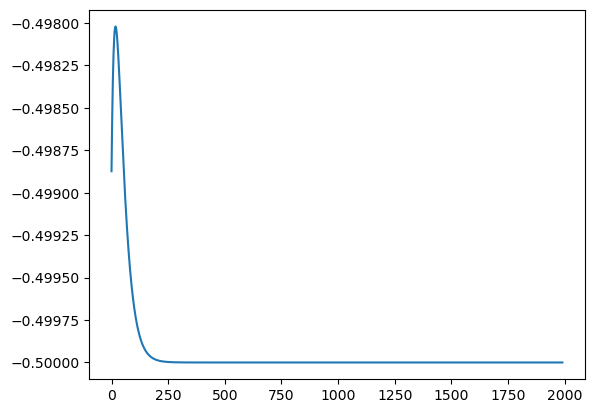

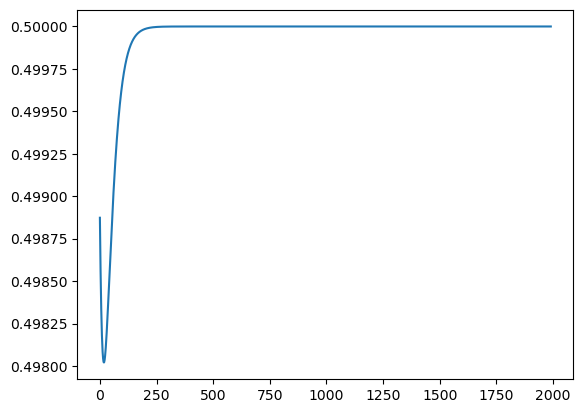

In [86]:
plt.plot(alphas)
plt.show()

plt.plot(betas)
plt.show()

In [87]:
print(f"alpha={alpha}, beta={beta}")

alpha=0.5, beta=0.5


In [88]:
print(f"rho={eps/mu}, k={k}")
print(f"rho_hat={eps/(mu*k)} < 1")

rho=0.5, k=1
rho_hat=0.5 < 1


In [89]:
t = np.arange(1, 200.0001, dt)
skip = 1
xsa = np.array(xs)
nsa = f(k,np.array(ns))
xsa = xsa[::skip][:int(xsa.shape[0]/4)]
nsa = nsa[::skip][:int(xsa.shape[0]/4)]
t = t[::skip][:int(xsa.shape[0]/4)]
make_xn_time_video(xsa, nsa, t=t, name="case1_upto1", frames_dir="frames", fps=15, out_size=(1440,1080))

Saved video: /home/sudo-1046372/Code/dynamics_dormancy/case1_upto1.mp4
Saved frames to: /home/sudo-1046372/Code/dynamics_dormancy/frames


### 2. Persistence without macroscopic growth (Dormancy)

\begin{equation}
\begin{aligned}
M_h =
     \begin{bmatrix}
       0 & \beta \\
      \alpha & 0
     \end{bmatrix}, \qquad
M_s =
     \begin{bmatrix}
       0 & -\beta \\
       \alpha & 0
     \end{bmatrix}
\end{aligned}
\end{equation}
so,
\begin{equation}
\begin{aligned}
M(n) &=  \left(1-\frac{n}{n+k}\right)
     \begin{bmatrix}
       0 & \beta \\
      \alpha & 0
     \end{bmatrix} +
     \left(\frac{n}{n+k}\right)
     \begin{bmatrix}
       0 & -\beta \\
       \alpha & 0
     \end{bmatrix} \\
     &= 
    \begin{bmatrix}
       \displaystyle 0 & \displaystyle -\beta\frac{(n-k)}{n+k} \\
       \displaystyle \alpha & \displaystyle 0
    \end{bmatrix}
\end{aligned}
\end{equation}
This way, the dynamics of the cancer cells population is,
\begin{equation}
    \dot{x_2} = x_2(1-x_2)\left( \beta\left( \frac{n-k}{n+k}\right) x_2 + \alpha(1-x_2)\right)
\end{equation}

### $\rho<k$

In [90]:
def f(k,n):
    return n / (n+k)

def x(x,alphan,betan,dt):
    return (x*(1-x)*(-(alphan+betan)*x+alphan))*dt + x

def n(n,x,eps,mu,dt):
    return (eps*x - mu*n)*dt + n

def Msfunc(alpha,beta):
    return np.array([[0, -beta],
                     [alpha, 0]])

def Mhfunc(alpha,beta):
    return np.array([[0, beta],
                     [alpha, 0]])

def Mn(f_n,Mh,Ms):
    return (1-f_n)*Mh + f_n*Ms

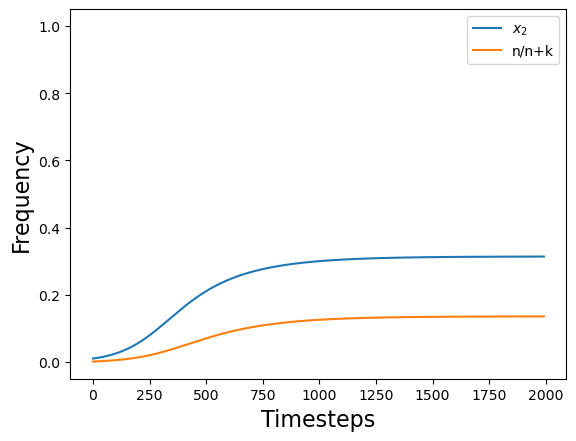

In [91]:
alpha = 0.1
beta = 0.3
eps = 0.04
mu = 0.08
k = 1

dt = 0.1
x20 = 0.01
n0 = 0.001

Mh, Ms = Mhfunc(alpha,beta), Msfunc(alpha,beta)

xs = [x20]
ns = [n0]

alphas = []
betas = []

for t in np.arange(1, 200.0001, dt):
    ns.append(n(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(f(k,ns[-1]), Mh,Ms)
    alphan = M[1,0]
    alphas.append(alphan)
    betan = M[0,1]
    betas.append(betan)
    xs.append(x(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

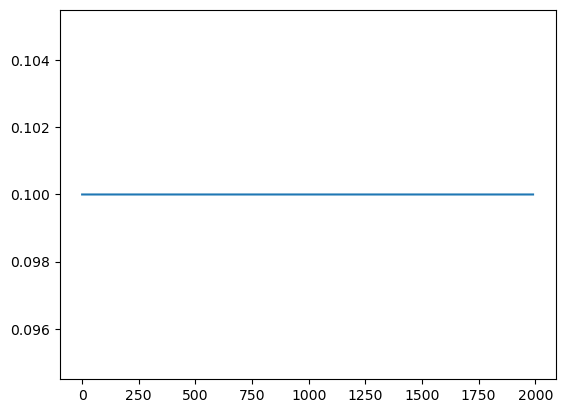

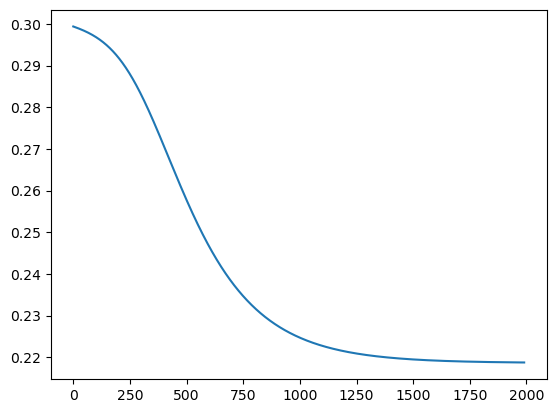

In [92]:
plt.plot(alphas)
plt.show()

plt.plot(betas)
plt.show()

In [93]:
print(f"alpha={alpha}, beta={beta}")

alpha=0.1, beta=0.3


In [94]:
print(f"rho={eps/mu} < k={k}")
print(f"rho_hat={eps/(mu*k)} < 1")

rho=0.5 < k=1
rho_hat=0.5 < 1


In [95]:
t = np.arange(1, 200.0001, dt)
skip = 2
xsa = np.array(xs)
nsa = f(k,np.array(ns))
divide = 1
xsa = xsa[::skip][:int(xsa.shape[0]/1)]
nsa = nsa[::skip][:int(xsa.shape[0]/1)]
t = t[::skip][:int(xsa.shape[0]/1)]
make_xn_time_video(xsa, nsa, t=t, name="case2_upto1", frames_dir="frames", fps=120, out_size=(1440,1080))

Saved video: /home/sudo-1046372/Code/dynamics_dormancy/case2_upto1.mp4
Saved frames to: /home/sudo-1046372/Code/dynamics_dormancy/frames


### 3. Awakening / metastatic outgrowth

$$M
=
(1-f(n))M_h + f(n)M_s
= 
(1-f(n))\begin{bmatrix}
0 & \beta \\
\alpha & 0
\end{bmatrix}
+
f(n)\begin{bmatrix}
0 & -\beta \\
\alpha & 0
\end{bmatrix}
$$

### $\rho>k$

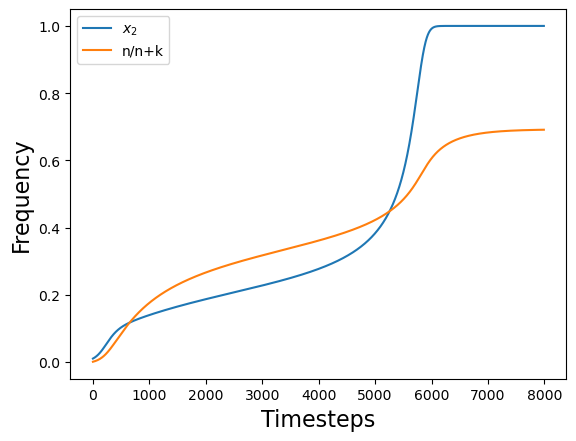

In [96]:
alpha = 0.1
beta = 0.9
eps = 0.09
mu = 0.02
k = 2

dt = 0.1
x20 = 0.01
n0 = 0.001

Mh, Ms = Mhfunc(alpha,beta), Msfunc(alpha,beta)

xs = [x20]
ns = [n0]
alphas = []
betas = []

for t in np.arange(1, 800.0001, dt):
    ns.append(n(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(f(k,ns[-1]), Mh,Ms)
    alphan = M[1,0]
    alphas.append(alphan)
    betan = M[0,1]
    betas.append(betan)
    xs.append(x(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(f(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

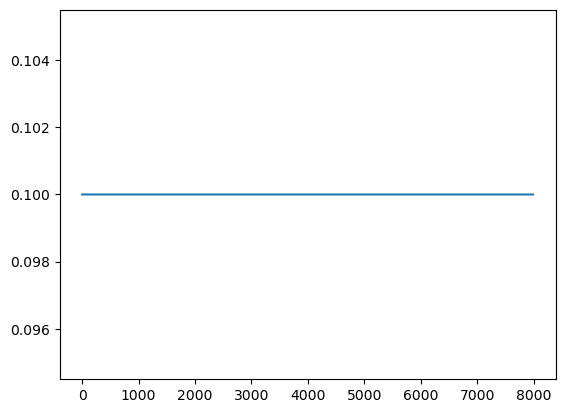

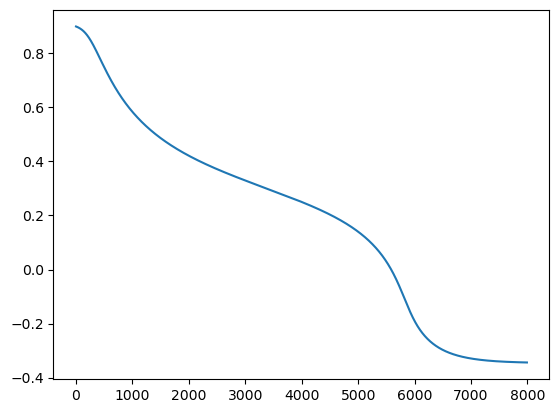

In [97]:
plt.plot(alphas)
plt.show()

plt.plot(betas)
plt.show()

In [98]:
print(f"alpha={alpha}, beta={beta}")

alpha=0.1, beta=0.9


In [99]:
print(f"rho={eps/mu} > k={k}")
print(f"rho_hat={eps/(mu*k)} > 1")

rho=4.5 > k=2
rho_hat=2.25 > 1


In [100]:
t = np.arange(1, 800.0001, dt)
skip = 8
xsa = np.array(xs)
nsa = f(k,np.array(ns))
divide = 1
xsa = xsa[::skip][:int(xsa.shape[0]/1)]
nsa = nsa[::skip][:int(xsa.shape[0]/1)]
t = t[::skip][:int(xsa.shape[0]/1)]
make_xn_time_video(xsa, nsa, t=t, name="case3_upto1", frames_dir="frames", fps=120, out_size=(1440,1080))

Saved video: /home/sudo-1046372/Code/dynamics_dormancy/case3_upto1.mp4
Saved frames to: /home/sudo-1046372/Code/dynamics_dormancy/frames


### 4. Multi-wave seeding / priming-driven relapse (history dependence) --> Vanishes

\begin{equation}
\begin{aligned}
M_h =
     \begin{bmatrix}
       0 & \beta \\
      -\alpha & 0
     \end{bmatrix}, \qquad
M_s =
     \begin{bmatrix}
       0 & -\beta \\
       \alpha & 0
     \end{bmatrix}
\end{aligned}
\end{equation}
so,
\begin{equation}
\begin{aligned}
M(n) &=  \left(1-\frac{n}{n+k}\right)
     \begin{bmatrix}
       0 & \beta \\
      -\alpha & 0
     \end{bmatrix} +
     \left(\frac{n}{n+k}\right)
     \begin{bmatrix}
       0 & -\beta \\
       \alpha & 0
     \end{bmatrix} \\
     &= 
    \begin{bmatrix}
       \displaystyle 0 & \displaystyle -\beta\frac{(n-k)}{n+k} \\
       \displaystyle \alpha\frac{(n-k)}{n+k} & \displaystyle 0
    \end{bmatrix}
\end{aligned}
\end{equation}
This way,
\begin{equation}
    \dot{x_2} = x_2(1-x_2)\left( \frac{n-k}{n+k}\right) \bigl(\beta x_2 + \alpha(1-x_2) \bigr)
\end{equation}

In [68]:
def switch(k,n):
    return n/(n+k)

def x_2(x2,alphan,betan,dt):
    return (x2*(1-x2)*(-(alphan+betan)*x2+alphan))*dt + x2

def nfunc(n,x2,eps,mu,dt):
    return (eps*x2 - mu*n)*dt + n

def Mhfunc(alpha,beta):
    return np.array([[0, beta],
                     [-alpha, 0]])

def Msfunc(alpha,beta):
    return np.array([[0, -beta],
                     [alpha, 0]])

def Mn(sw,Mh,Ms):
    return (1-sw)*Mh + sw*Ms

### $\rho>k$

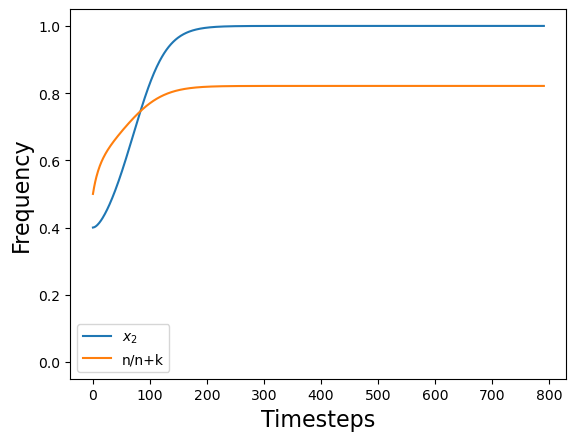

In [69]:
alpha = 0.5
beta = 0.6
eps = 0.23
mu = 0.5
k = 0.1

dt = 0.1
x20 = 0.4
n0 = 0.1

Mh, Ms = Mhfunc(alpha,beta), Msfunc(alpha,beta)

xs = [x20]
ns = [n0]
alphas = []
betas = []

for t in np.arange(1, 80.0001, dt):
    ns.append(nfunc(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(switch(k,ns[-1]), Mh,Ms)
    alphan = M[1,0]
    alphas.append(alphan)
    betan = M[0,1]
    betas.append(betan)
    xs.append(x_2(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(switch(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

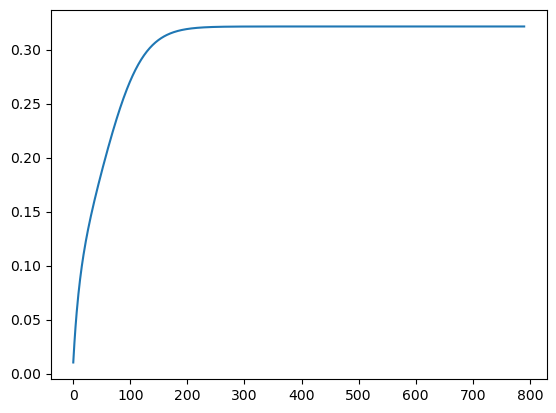

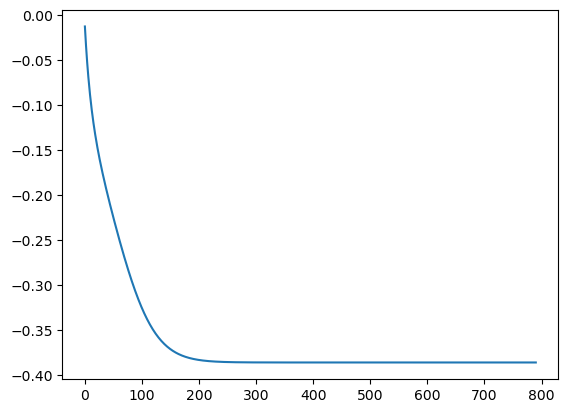

In [70]:
plt.plot(alphas)
plt.show()

plt.plot(betas)
plt.show()

In [71]:
print(f"alpha={alpha}, beta={beta}")
print(f"rho={eps/mu} > k={k}")
print(f"rho_hat={eps/(mu*k)} > 1")

alpha=0.5, beta=0.6
rho=0.46 > k=0.1
rho_hat=4.6 > 1


In [77]:
t = np.arange(1, 80.0001, dt)
skip = 1
xsa = np.array(xs)
nsa = f(k,np.array(ns))
divide = 1.5
xsa = xsa[::skip][:int(xsa.shape[0]/divide)]
nsa = nsa[::skip][:int(xsa.shape[0]/divide)]
t = t[::skip][:int(xsa.shape[0]/divide)]
make_xn_time_video(xsa, nsa, t=t, name="case4", frames_dir="frames", fps=60, out_size=(1440,1080))

Saved video: /home/sudo-1046372/Code/dynamics_dormancy/case4.mp4
Saved frames to: /home/sudo-1046372/Code/dynamics_dormancy/frames


### 5. Multi-wave seeding / priming-driven relapse (history dependence) --> Take over

### $\rho>k$

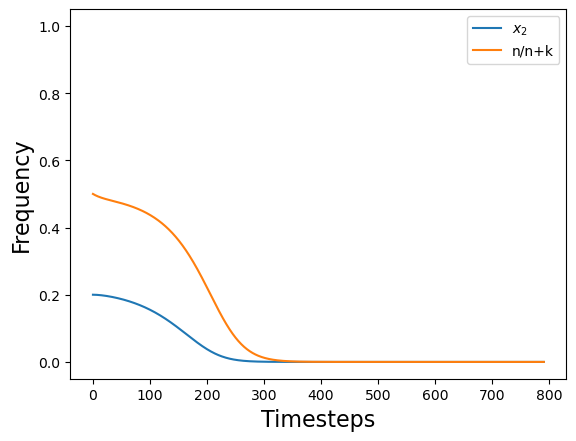

In [78]:
alpha = 0.5
beta = 0.6
eps = 0.23
mu = 0.5
k = 0.1

dt = 0.1
x20 = 0.2
n0 = 0.1

Mh, Ms = Mhfunc(alpha,beta), Msfunc(alpha,beta)

xs = [x20]
ns = [n0]
alphas = []
betas = []

for t in np.arange(1, 80.0001, dt):
    ns.append(nfunc(ns[-1],xs[-1],eps,mu,dt))
    M = Mn(switch(k,ns[-1]), Mh,Ms)
    alphan = M[1,0]
    alphas.append(alphan)
    betan = M[0,1]
    betas.append(betan)
    xs.append(x_2(xs[-1],alphan,betan,dt))
    
plt.plot(xs, label='$x_2$')
plt.plot(switch(k,np.array(ns)), label='n/n+k')# label='$\frac{n}{k+n}$')
plt.legend()
plt.xlabel('Timesteps',fontsize=16)
plt.ylabel('Frequency',fontsize=16)
plt.ylim(-0.05,1.05)
plt.show()

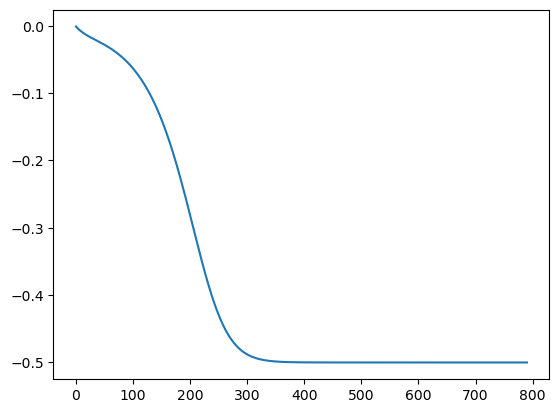

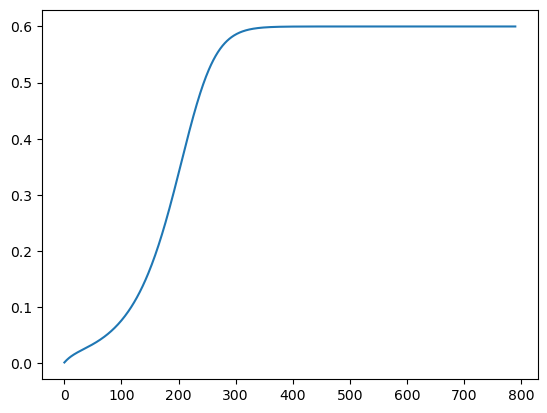

In [79]:
plt.plot(alphas)
plt.show()

plt.plot(betas)
plt.show()

In [80]:
print(f"alpha={alpha}, beta={beta}")
print(f"rho={eps/mu} > k={k}")
print(f"rho_hat={eps/(mu*k)} > 1")

alpha=0.5, beta=0.6
rho=0.46 > k=0.1
rho_hat=4.6 > 1


In [83]:
t = np.arange(1, 80.0001, dt)
skip = 1
xsa = np.array(xs)
nsa = f(k,np.array(ns))
divide = 1.5
xsa = xsa[::skip][:int(xsa.shape[0]/divide)]
nsa = nsa[::skip][:int(xsa.shape[0]/divide)]
t = t[::skip][:int(xsa.shape[0]/divide)]
make_xn_time_video(xsa, nsa, t=t, name="case5", frames_dir="frames", fps=60, out_size=(1440,1080))

Saved video: /home/sudo-1046372/Code/dynamics_dormancy/case5.mp4
Saved frames to: /home/sudo-1046372/Code/dynamics_dormancy/frames
